# 00 - Data Understanding

## Project
**Machine Learning Analysis of Life Satisfaction Among Foreign Residents in Seoul**

## Main Objective
To analyze and predict life satisfaction among foreign residents in Seoul using demographic, socioeconomic, linguistic, health, and social-integration factors from the 2025 Seoul Survey.

This notebook focuses only on understanding the raw data before preprocessing or model training.


## 1. Import Libraries


In [18]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)


## 2. Locate the Raw Dataset


In [19]:
DATA_PATH = Path("../data/raw/seoul_survey_foreigners_2025.xlsx")

print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())


Dataset path: ..\data\raw\seoul_survey_foreigners_2025.xlsx
Dataset exists: True


## 3. Inspect the Excel Workbook

Before loading the survey, inspect the available sheet names. This helps identify the main data sheet and the codebook sheet without making assumptions about their exact names.


In [20]:
xls = pd.ExcelFile(DATA_PATH)

print("Available sheets:")
for i, sheet in enumerate(xls.sheet_names):
    print(f"{i}: {sheet}")


Available sheets:
0: 2025년 서울서베이_외국인_data(260323,  구
1: 코드북


## 4. Load the Survey Data and Codebook

The first sheet is loaded as the survey dataset. A sheet containing the word `코드북` is loaded as the codebook when available.


In [21]:
data_sheet = xls.sheet_names[0]

codebook_candidates = [
    sheet for sheet in xls.sheet_names
    if "코드북" in str(sheet)
]

codebook_sheet = codebook_candidates[0] if codebook_candidates else None

df = pd.read_excel(DATA_PATH, sheet_name=data_sheet)

if codebook_sheet is not None:
    codebook = pd.read_excel(DATA_PATH, sheet_name=codebook_sheet)
else:
    codebook = None

print("Data sheet:", data_sheet)
print("Codebook sheet:", codebook_sheet)
print("Dataset shape:", df.shape)


Data sheet: 2025년 서울서베이_외국인_data(260323,  구
Codebook sheet: 코드북
Dataset shape: (2500, 157)


## 5. Preview the Raw Dataset

The first rows are inspected to understand how respondents and survey variables are represented.


In [22]:
df.head()


,ID,AREA,SQ1,SQ1_1,SQ2,SQ2_1,SQ2_1_1,SQ3,SQ4_1,SQ4_2,SQ5,SQ6,SQ6_1,SQ6_2,SQ7,SQ8,Q1_1,Q1_2,Q1_3,Q1_4,Q2,Q2_1,Q3,Q3_1,Q4_1,Q4_2,Q4_3,Q4_4,Q4_5,Q4_6,Q4_7,Q5,Q6_1,Q6_2,Q6_3,Q6_4,Q6_5,Q6_6,Q6_7,Q6_8,Q6_9,Q6_10,Q6_11,Q6_12,Q7_1,Q7_2,Q7_3,Q7_4,Q7_5,Q7_6,Q7_7,Q8_1,Q8_2,Q9_1,Q9_2,Q9_3,Q9_4,Q9_5,Q10_1,Q10_2,Q10_3,Q10_4,Q10_5,Q11,Q12,Q13_1,Q13_2,Q13_3,Q13_4,Q13_5,Q13_6,Q13_7,Q13_8,Q14,Q14_1,Q15,Q16,Q16_1,Q17_1,Q17_2,Q17_3,Q17_4,Q18,Q19_1,Q19_2,Q19_3,Q19_4,Q20_1,Q20_2,Q20_3,Q20_4,Q21_1,Q21_2,Q21_3,Q21_4,Q21_5,Q21_6,Q21_7,Q22_1,Q22_2,Q22_3,Q22_4,Q23_1_1,Q23_1_2,Q23_1_3,Q23_1_4,Q23_1_5,Q23_1_6,Q23_1_7,Q23_1_8,Q23_1_9,Q23_1_10,Q23_2_1,Q23_2_2,Q23_2_3,Q23_2_4,Q23_2_5,Q23_2_6,Q23_2_7,Q23_2_8,Q23_2_9,Q23_2_10,Q24_1,Q24_2,Q24_3,Q24_4,Q24_5,Q25_1,Q25_2,Q26,Q27_1,Q27_2,Q27_3,Q28,Q28_1,Q29_1,Q29_2,Q29_3,Q29_4,Q30_1,Q30_2,Q31,DQ1,DQ2,DQ3,DQ4_1,DQ4_2,DE01,DE02,DE03,DE04,DE05,DE06,DE07,DE08,RIM_WT,RIM_WT1
0,1,10,9,904,2,2,NaN,1990,5,9,5,3,2000.0,70.0,1,2,2,2,1,3,5,1.0,1,5.0,3,3,2,4,3,4,3,5,5,9,4,2,3,3,4,4,4,3,3,4,5,3,3,3,3,4,3,8,6.0,2,2,4,4,3,8,6,6,5,6,7,120,5,6.0,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,4,5,NaN,1,NaN,NaN,NaN,4,2,1,2,1,3,2,2,5,12,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,2,2,2,2,2,2,2,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1,1,4,3,2,NaN,4,1,2.0,3.0,2,5.0,1,NaN,NaN,NaN,2,3.0,1,2,1.0,12.0,8,1,9,1,2,5,2,5,3,1,29.205606,0.194471
1,2,10,6,609,1,2,NaN,2000,1,0,3,3,1000.0,60.0,1,1,4,2,2,4,4,2.0,2,NaN,3,3,4,4,3,5,3,5,3,9,3,1,2,3,3,9,3,4,2,5,5,4,5,3,3,4,3,6,8.0,2,3,5,5,5,8,6,6,7,5,6,140,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,2,3,4.0,1,NaN,NaN,NaN,3,2,2,3,1,2,3,2,4,9,NaN,NaN,NaN,NaN,NaN,NaN,2,3,2,8,2,2,2,2,2,2,2,1,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,3.0,NaN,3,2,9,3,3,1,NaN,4,1,5.0,9.0,2,6.0,7,NaN,NaN,NaN,3,1.0,1,4,2.0,4.0,4,1,6,1,1,2,1,3,3,3,28.202208,0.187790
2,3,10,9,901,2,2,NaN,1979,14,5,6,5,NaN,NaN,1,11,3,2,2,3,4,1.0,1,4.0,4,3,3,3,3,4,4,4,3,3,2,1,2,4,3,4,4,2,4,4,5,4,4,3,3,4,4,1,6.0,3,3,4,4,4,7,7,7,8,8,8,130,2,5.0,8.0,NaN,NaN,NaN,NaN,NaN,4,NaN,4,1,3.0,1,NaN,NaN,NaN,3,4,2,4,2,4,4,4,5,6,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2,3,1,2,2,2,2,2,2,2,2,2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1,1,3,2,2,NaN,5,1,2.0,4.0,2,1.0,4,5.0,NaN,NaN,4,6.0,5,2,1.0,18.0,8,1,9,1,3,5,2,5,5,2,52.991877,0.352857
3,4,10,7,7,2,2,NaN,1991,3,5,1,3,2000.0,80.0,2,2,4,3,3,4,4,1.0,2,NaN,4,4,5,4,3,5,3,5,3,9,2,1,3,3,3,4,3,2,5,4,5,4,5,4,4,5,3,1,4.0,2,2,4,5,5,9,8,8,9,8,9,70,2,3.0,5.0,8.0,NaN,NaN,NaN,NaN,5,NaN,5,5,NaN,1,NaN,NaN,NaN,4,4,3,4,1,4,3,3,5,5,6.0,8.0,NaN,NaN,NaN,NaN,2,2,4,4,1,2,2,2,2,2,2,2,2,2,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2,1,2,2,2,NaN,5,1,4.0,3.0,2,6.0,1,NaN,NaN,NaN,2,4.0,3,2,1.0,10.0,5,1,7,2,2,4,2,1,3,1,44.217196,0.294429
4,5,10,6,619,1,2,NaN,1985,0,9,6,3,100.0,40.0,1,11,3,2,1,4,3,1.0,1,4.0,4,4,3,4,3,3,2,4,4,9,3,2,2,3,3,9,3,9,3,5,5,3,5,4,3,5,5,1,6.0,3,3,4,4,4,9,6,7,7,6,7,80,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,4,5,NaN,1,NaN,NaN,NaN,4,4,3,4,3,3,3,4,5,6,9.0,NaN,NaN,NaN,NaN,NaN,2,10,2,2,1,2,2,2,2,2,2,1,2,2,3.0,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,3,1,9,2,2,2,NaN,4,1,4.0,2.0,2,7.0,3,NaN,NaN,NaN,3,4.0,3,3,1.0,5.0,5,1,6,1,3,1,1,5,3,2,59.107090,0.393576


## 6. Dataset Dimensions

The number of rows represents respondents and the number of columns represents available variables.


In [23]:
n_rows, n_cols = df.shape

print(f"Number of respondents: {n_rows:,}")
print(f"Number of variables: {n_cols:,}")


Number of respondents: 2,500
Number of variables: 157


## 7. Column Names

Review all available variables before selecting features for each research objective.


In [24]:
column_table = pd.DataFrame({
    "column_number": range(1, len(df.columns) + 1),
    "variable": df.columns.astype(str)
})

column_table


,column_number,variable
0,1,ID
1,2,AREA
2,3,SQ1
3,4,SQ1_1
4,5,SQ2
5,6,SQ2_1
6,7,SQ2_1_1
7,8,SQ3
8,9,SQ4_1
9,10,SQ4_2


## 8. Data Types

Data types provide an initial indication of which variables are numeric, categorical, or stored as text.


In [25]:
dtype_summary = (
    df.dtypes
      .astype(str)
      .value_counts()
      .rename_axis("data_type")
      .reset_index(name="number_of_columns")
)

dtype_summary


,data_type,number_of_columns
0,int64,111
1,float64,46


In [26]:
variable_types = pd.DataFrame({
    "variable": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null": df.notna().sum().values,
    "unique_values": df.nunique(dropna=True).values
})

variable_types.head(30)


,variable,dtype,non_null,unique_values
0,ID,int64,2500,2500
1,AREA,int64,2500,25
2,SQ1,int64,2500,10
3,SQ1_1,int64,2500,89
4,SQ2,int64,2500,9
5,SQ2_1,int64,2500,2
6,SQ2_1_1,float64,166,14
7,SQ3,int64,2500,53
8,SQ4_1,int64,2500,33
9,SQ4_2,int64,2500,12


## 9. Duplicate Rows

Duplicate records are checked before any transformations are applied.


In [27]:
duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)


Duplicate rows: 0


## 10. Missing Values

Missingness is examined for every variable. At this stage, missing values are not modified because some survey questions may be conditional or not applicable to every respondent.


In [28]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
})

missing_summary = missing_summary.sort_values(
    "missing_percent",
    ascending=False
)

missing_summary.head(30)


,missing_count,missing_percent
Q23_2_10,2500,100.00
Q29_4,2499,99.96
Q17_4,2497,99.88
Q13_8,2496,99.84
Q17_3,2490,99.60
Q21_7,2489,99.56
Q13_7,2482,99.28
Q21_6,2479,99.16
Q29_3,2459,98.36
Q13_6,2443,97.72


In [29]:
missing_overview = pd.DataFrame({
    "variables_with_no_missing": [(missing_summary["missing_count"] == 0).sum()],
    "variables_with_missing": [(missing_summary["missing_count"] > 0).sum()],
    "variables_over_25_percent_missing": [(missing_summary["missing_percent"] > 25).sum()],
    "variables_over_50_percent_missing": [(missing_summary["missing_percent"] > 50).sum()]
})

missing_overview


,variables_with_no_missing,variables_with_missing,variables_over_25_percent_missing,variables_over_50_percent_missing
0,113,44,36,30


## 11. Missing-Value Distribution

This visualization shows which variables contain the highest proportion of missing observations.


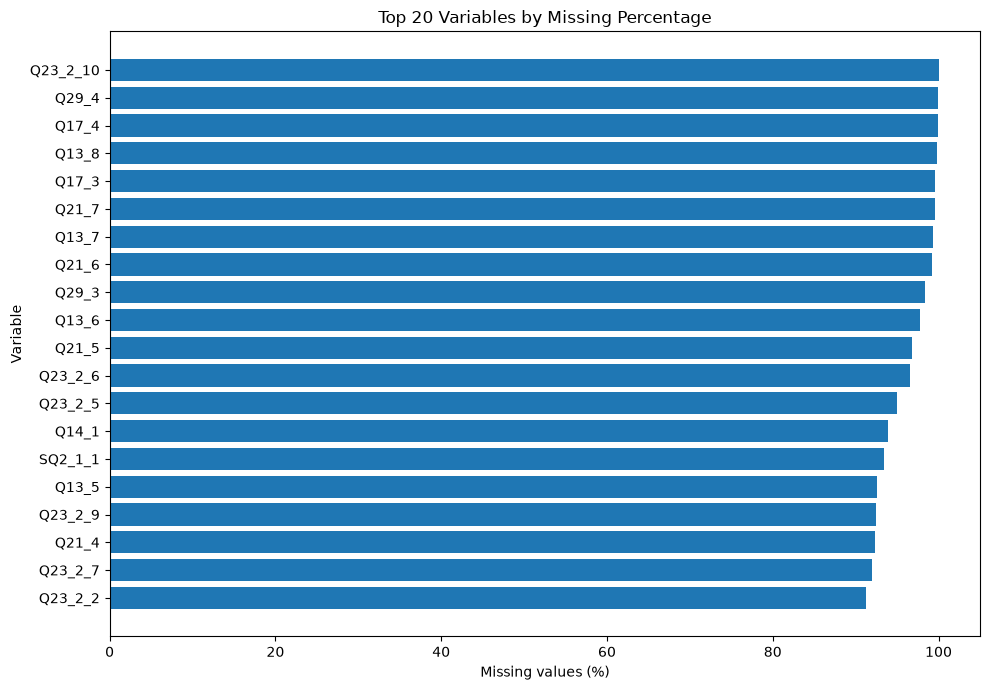

In [30]:
top_missing = missing_summary.head(20).sort_values("missing_percent")

plt.figure(figsize=(10, 7))
plt.barh(top_missing.index.astype(str), top_missing["missing_percent"])
plt.xlabel("Missing values (%)")
plt.ylabel("Variable")
plt.title("Top 20 Variables by Missing Percentage")
plt.tight_layout()
plt.show()


## 12. Numeric Variable Summary

Descriptive statistics are reviewed for numeric variables to identify ranges, unusual values, and potential survey codes that require interpretation.


In [31]:
numeric_df = df.select_dtypes(include=np.number)

print("Number of numeric variables:", numeric_df.shape[1])

numeric_df.describe().T


Number of numeric variables: 157


,count,mean,std,min,25%,50%,75%,max
ID,2500.0,1253.271200,723.537015,1.000000,626.750000,1253.500000,1880.250000,2506.000000
AREA,2500.0,10.314800,6.226525,1.000000,5.000000,10.000000,17.000000,25.000000
SQ1,2500.0,4.387200,2.983427,1.000000,1.000000,4.000000,7.000000,10.000000
SQ1_1,2500.0,248.138800,371.231254,1.000000,1.000000,4.000000,610.000000,1060.000000
SQ2,2500.0,4.616000,2.182120,1.000000,3.000000,5.000000,6.000000,9.000000
SQ2_1,2500.0,1.933600,0.249030,1.000000,2.000000,2.000000,2.000000,2.000000
SQ2_1_1,166.0,10.216867,8.785040,2.000000,4.000000,4.000000,12.000000,30.000000
SQ3,2500.0,1990.720800,10.302024,1941.000000,1985.000000,1992.000000,1999.000000,2005.000000
SQ4_1,2500.0,4.564000,5.016609,0.000000,1.000000,3.000000,7.000000,41.000000
SQ4_2,2500.0,3.485600,3.311643,0.000000,0.000000,3.000000,6.000000,11.000000


## 13. Categorical / Non-Numeric Variable Summary


In [32]:
categorical_df = df.select_dtypes(exclude=np.number)

print("Number of non-numeric variables:", categorical_df.shape[1])

if categorical_df.shape[1] > 0:
    display(categorical_df.describe().T)
else:
    print("No non-numeric columns were detected.")


Number of non-numeric variables: 0
No non-numeric columns were detected.


## 14. Inspect the Codebook

The codebook is used to interpret variable meanings and survey response codes before feature selection or preprocessing.


In [33]:
if codebook is not None:
    print("Codebook shape:", codebook.shape)
    display(codebook.head(30))
else:
    print("No codebook sheet was automatically detected.")


Codebook shape: (137, 5)


,변수 정보,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,변수,문항,변수설명,보기,비고
1,ID,NaN,NaN,NaN,NaN
2,AREA,NaN,자치구,1.종로구\n2.중구\n3.용산구\n4.성동구\n5.광진구\n6.동대문구\n7.중랑...,NaN
3,SQ1,NaN,국적,1.한국계중국인\n2.중국\n3.일본\n4.타이완\n5.베트남\n6.아시아기타\n7...,NaN
4,SQ1_1,NaN,국적_국가명,601. 몽골\n602. 우즈베키스탄\n603. 필리핀\n604. 방글라데시\n60...,NaN
5,SQ2,NaN,체류자격,"1.방문취업(H2)\n2.전문인력(E1~E7)\n3.유학(D2,D4)\n4.방문동거...",NaN
6,SQ2_1,NaN,최근 3년 체류자격 변화-여부,1.예\n2.아니오,NaN
7,SQ2_1_1,NaN,최근 3년 체류자격 변화-변경 전 체류자격,1.H2\n2.D2\n3.D4\n4.D8\n5.D10\n6.E2\n7.E9\n8.F...,NaN
8,SQ3,NaN,출생년도,NaN,단위: 년
9,SQ4_1,NaN,체류기간_년,NaN,단위: 년


## 15. Search the Codebook for Key Project Concepts

The project focuses on life satisfaction and potential explanatory dimensions such as language, employment, income, housing, health, discrimination, social relationships, belonging, and length of stay.


In [35]:
keywords = [
    "Q11",
    "만족",
    "생활",
    "한국어",
    "소득",
    "고용",
    "주거",
    "건강",
    "차별",
    "소속",
    "체류"
]

if codebook is not None:
    # Convert every cell safely to text and combine each row
    codebook_text = codebook.apply(
        lambda row: " ".join(row.fillna("").astype(str)),
        axis=1
    )

    keyword_matches = []

    for keyword in keywords:
        matches = codebook.loc[
            codebook_text.str.contains(
                keyword,
                case=False,
                na=False
            )
        ].copy()

        if not matches.empty:
            matches.insert(0, "search_keyword", keyword)
            keyword_matches.append(matches)

    if keyword_matches:
        keyword_matches = pd.concat(
            keyword_matches,
            ignore_index=True
        ).drop_duplicates()

        display(keyword_matches)
    else:
        print("No keyword matches were found.")

else:
    print("Codebook not available.")

,search_keyword,변수 정보,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,Q11,Q11,11,전반적 삶의 만족도,0.전혀 만족하지 않는다\n1.\n2.\n3.\n4.\n5.보통\n6.\n7.\n8...,NaN
1,만족,Q4_1,4-1,삶의 질 만족도_주거환경,1.매우 불만족\n2.다소 불만족\n3.보통\n4.다소 만족\n5.매우 만족,10점 환산 = (x-1)/4*10
2,만족,Q4_2,4-2,삶의 질 만족도_경제환경,1.매우 불만족\n2.다소 불만족\n3.보통\n4.다소 만족\n5.매우 만족,10점 환산 = (x-1)/4*10
3,만족,Q4_3,4-3,삶의 질 만족도_복지환경,1.매우 불만족\n2.다소 불만족\n3.보통\n4.다소 만족\n5.매우 만족,10점 환산 = (x-1)/4*10
4,만족,Q4_4,4-4,삶의 질 만족도_사회환경,1.매우 불만족\n2.다소 불만족\n3.보통\n4.다소 만족\n5.매우 만족,10점 환산 = (x-1)/4*10
5,만족,Q4_5,4-5,삶의 질 만족도_교육환경,1.매우 불만족\n2.다소 불만족\n3.보통\n4.다소 만족\n5.매우 만족,10점 환산 = (x-1)/4*10
6,만족,Q4_6,4-6,삶의 질 만족도_도시안전,1.매우 불만족\n2.다소 불만족\n3.보통\n4.다소 만족\n5.매우 만족,10점 환산 = (x-1)/4*10
7,만족,Q4_7,4-7,삶의 질 만족도_문화여가환경,1.매우 불만족\n2.다소 불만족\n3.보통\n4.다소 만족\n5.매우 만족,10점 환산 = (x-1)/4*10
8,만족,Q11,11,전반적 삶의 만족도,0.전혀 만족하지 않는다\n1.\n2.\n3.\n4.\n5.보통\n6.\n7.\n8...,NaN
9,만족,Q14,14,여가생활 만족도,1.매우 불만족\n2.다소 불만족\n3.보통\n4.다소 만족\n5.매우 만족,10점 환산 = (x-1)/4*10


## 16. Verify the Target Variable: Q11

The proposed target variable is `Q11`, representing overall life satisfaction. Its availability, data type, missingness, and value distribution are checked before any modeling decision is made.


In [ ]:
TARGET = "Q11"

if TARGET in df.columns:
    print("Target variable found:", TARGET)
    print("Data type:", df[TARGET].dtype)
    print("Missing values:", df[TARGET].isna().sum())
    print("Unique values:", sorted(df[TARGET].dropna().unique().tolist()))
else:
    print(f"{TARGET} was not found in the dataset.")


In [ ]:
if TARGET in df.columns:
    target_distribution = (
        df[TARGET]
        .value_counts(dropna=False)
        .sort_index()
        .rename("count")
        .to_frame()
    )

    target_distribution["percent"] = (
        target_distribution["count"] / len(df) * 100
    ).round(2)

    target_distribution


## 17. Visualize Overall Life Satisfaction


In [ ]:
if TARGET in df.columns:
    plt.figure(figsize=(9, 5))
    df[TARGET].dropna().hist(
        bins=range(
            int(df[TARGET].dropna().min()),
            int(df[TARGET].dropna().max()) + 2
        ),
        align="left",
        rwidth=0.85
    )
    plt.xlabel("Overall Life Satisfaction (Q11)")
    plt.ylabel("Number of Respondents")
    plt.title("Distribution of Overall Life Satisfaction")
    plt.tight_layout()
    plt.show()


In [ ]:
if TARGET in df.columns:
    df[TARGET].describe()


## 18. Inspect Core Candidate Variables

The following variables are checked because they are expected to be relevant to the project's main objective. This is an exploratory inventory only; final feature selection will be performed after reviewing the codebook and potential target leakage.


In [ ]:
candidate_variables = [
    "Q11",
    "SQ1",
    "SQ2",
    "SQ3",
    "SQ4_1",
    "SQ4_2",
    "SQ5",
    "SQ6",
    "SQ7",
    "Q1_1",
    "Q1_2",
    "Q1_3",
    "Q1_4"
]

available_candidates = [
    col for col in candidate_variables
    if col in df.columns
]

candidate_summary = pd.DataFrame({
    "variable": available_candidates,
    "dtype": [str(df[col].dtype) for col in available_candidates],
    "non_null": [df[col].notna().sum() for col in available_candidates],
    "missing": [df[col].isna().sum() for col in available_candidates],
    "unique_values": [df[col].nunique(dropna=True) for col in available_candidates]
})

candidate_summary


## 19. Inspect Values of Core Candidate Variables

Value counts help determine whether survey variables should later be treated as nominal categorical, ordinal, or numeric.


In [ ]:
for col in available_candidates:
    print("\n" + "=" * 70)
    print(col)
    print("=" * 70)
    print(df[col].value_counts(dropna=False).sort_index().head(30))


## 20. Preliminary Numeric Relationship with Q11

A preliminary correlation check is performed only for numeric variables. This does not determine final feature importance; it is an initial exploration of linear associations.


In [ ]:
if TARGET in df.columns and pd.api.types.is_numeric_dtype(df[TARGET]):
    numeric_correlations = (
        df.select_dtypes(include=np.number)
          .corr(numeric_only=True)[TARGET]
          .drop(TARGET, errors="ignore")
          .dropna()
          .sort_values(key=lambda s: s.abs(), ascending=False)
          .to_frame("correlation_with_Q11")
    )

    numeric_correlations.head(20)


## 21. Visualize the Strongest Preliminary Numeric Associations

Only the strongest numeric correlations are visualized here. Survey coding and conceptual overlap with the target must still be reviewed before these variables are used in a machine learning model.


In [ ]:
if TARGET in df.columns and "numeric_correlations" in globals():
    top_corr = numeric_correlations.head(15).sort_values("correlation_with_Q11")

    plt.figure(figsize=(10, 6))
    plt.barh(top_corr.index.astype(str), top_corr["correlation_with_Q11"])
    plt.xlabel("Correlation with Q11")
    plt.ylabel("Variable")
    plt.title("Strongest Preliminary Numeric Associations with Life Satisfaction")
    plt.tight_layout()
    plt.show()


## 22. Dataset Understanding Summary

At the end of the data-understanding stage, the project should have established:

- the size and structure of the foreign-resident dataset;
- the available survey variables and their data types;
- the extent and pattern of missing values;
- whether duplicate observations exist;
- the meaning and distribution of the target variable `Q11`;
- the survey codebook needed to interpret coded responses;
- the main candidate feature groups for the four team research objectives;
- variables that require closer examination before preprocessing because of conditional survey logic or possible overlap with the target.

No missing-value imputation, encoding, scaling, train/test split, or model training is performed in this notebook.


## 23. Export Data-Understanding Tables

The raw data are not modified. Only summary tables generated during this notebook are exported for documentation and later team review.


In [ ]:
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

column_table.to_csv(
    RESULTS_DIR / "data_understanding_columns.csv",
    index=False
)

variable_types.to_csv(
    RESULTS_DIR / "data_understanding_variable_types.csv",
    index=False
)

missing_summary.to_csv(
    RESULTS_DIR / "data_understanding_missing_values.csv"
)

if TARGET in df.columns:
    target_distribution.to_csv(
        RESULTS_DIR / "data_understanding_Q11_distribution.csv"
    )

if "numeric_correlations" in globals():
    numeric_correlations.to_csv(
        RESULTS_DIR / "data_understanding_Q11_numeric_correlations.csv"
    )

print("Summary tables exported to:", RESULTS_DIR.resolve())


## 24. Final Check


In [ ]:
print("Data-understanding notebook completed successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Duplicate rows: {duplicate_rows:,}")

if TARGET in df.columns:
    print(f"Q11 non-missing observations: {df[TARGET].notna().sum():,}")
    print(f"Q11 missing observations: {df[TARGET].isna().sum():,}")
